In [15]:
import os
import sys 
sys.path.append(os.path.join('..'))


import numpy as np
import torch
import torch.nn.functional as F

from ops.torch_warping import warp_img_torch_3D
from ops.torch_algebra import random_affine_matrix

import nibabel as nib

from pytorch3d.ops import sample_points_from_meshes, cubify
from pytorch3d.transforms import axis_angle_to_matrix, matrix_to_axis_angle

import pyvista as pv
pv.start_xvfb(wait=0)
pv.set_jupyter_backend('html')

import trimesh

import pickle

from GHD.GHD_cardiac import GHD_Cardiac
from GHD import GHD_config

from data_process.dataset_real_scaling import *
import data.data_utils as dut
from torch_scatter import scatter
from einops import rearrange
from ops.medical_related import *

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# just load the canonical model

root_path = os.path.dirname(os.path.realpath('.'))

base_shape_path = 'canonical_shapes/Standard_LV_2000.obj'
base_shape_path = os.path.join(root_path, base_shape_path)
bi_ventricle_path = 'canonical_shapes/Standard_BiV.obj'
bi_ventricle_path = os.path.join(root_path, bi_ventricle_path)

# base_shape_path = 'metadata/Standard_LV.obj'
# bi_ventricle_path = 'metadata/Standard_BiV.obj'

cfg = GHD_config(base_shape_path=base_shape_path,
            num_basis=6**2, mix_laplacian_tradeoff={'cotlap':1.0, 'dislap':0.1, 'stdlap':0.1},
            device=device,
            if_nomalize=True, if_return_scipy=True, 
            bi_ventricle_path=bi_ventricle_path)

paraheart = GHD_Cardiac(cfg) # 

GHD config:
base_shape_path /home/fanwen/GHDHeart/canonical_shapes/Standard_LV_2000.obj
num_basis 36
device cuda:0
mix_laplacian_tradeoff {'cotlap': 1.0, 'dislap': 0.1, 'stdlap': 0.1}
if_lap_nomalize True
eign_path None
if_nomalize True
if_return_scipy True
bi_ventricle_path /home/fanwen/GHDHeart/canonical_shapes/Standard_BiV.obj


In [17]:
# follow the manner of MMWHS dense CT.
# flags: 
center_aligned = True
rescalar = 1/100
rootdir = '/media/ssd/fanwen/MultiView/HRUKBB/Dataset/'
casesnum = os.listdir(rootdir)
showcase = '150'
hr_ed_nii_path = os.path.join(rootdir, showcase, 'HR_ES.nii.gz')
# hr_es_nii_path = os.path.join(rootdir, showcase, 'HR_ES.nii.gz')
output = dut.load_nib_image(hr_ed_nii_path)

label_torch = torch.from_numpy(output['img']).permute(2,1,0).unsqueeze(0).float()

affine_torch = torch.from_numpy(output['affine']).float()
window_size = torch.from_numpy(output['window_size']).float()

affine_t2w_ = dut.affine_np2torch_new(output['affine'],
                               output['img'].shape,
                               rescalar = rescalar,
                               center_aligned = center_aligned)

In [18]:
B = 1
label_tem = label_torch.clone().unsqueeze(1).to(device)
affine_tem = affine_t2w_.clone().to(device)
coordinate_map_tem = dut.get_coord_map_3d_normalized_new(label_tem.shape[-3:], 
                                                     affine_tem)

B, C, Z, Y, X = label_tem.shape


Z_rv, Y_rv, X_rv = torch.where(label_tem[0, 0]==4)
Z_lv, Y_lv, X_lv = torch.where(label_tem[0, 0]==2)
Z_cav, Y_cav, X_cav = torch.where(label_tem[0, 0]==1)
Z_bg, Y_bg, X_bg = torch.where(label_tem[0, 0]==0)
Z_point, Y_point, X_point = torch.where(label_tem[0, 0]==3)

Pt_rv = coordinate_map_tem[0, Z_rv, Y_rv, X_rv]
Pt_lv = coordinate_map_tem[0, Z_lv, Y_lv, X_lv]
Pt_cav = coordinate_map_tem[0, Z_cav, Y_cav, X_cav]
Pt_bg = coordinate_map_tem[0, Z_bg, Y_bg, X_bg]

points_bi = torch.cat([Pt_rv, Pt_lv], dim=0)
points_lv = Pt_lv
points_outoflv = torch.cat([Pt_rv, Pt_cav, Pt_bg], dim=0)

geom_dict = get_4chamberview_frame_rv(Pt_cav, Pt_lv, Pt_rv)
inital_affine = geom_dict['target_affine']


bbox_lv = torch.stack([Pt_lv.min(dim=0)[0]-0.05, Pt_lv.max(dim=0)[0]+0.05], dim=-1)

points_outoflv_in_bbox = points_outoflv[(points_outoflv[:,0]>bbox_lv[0,0]) & (points_outoflv[:,0]<bbox_lv[0,1]) & (points_outoflv[:,1]>bbox_lv[1,0]) & (points_outoflv[:,1]<bbox_lv[1,1]) & (points_outoflv[:,2]>bbox_lv[2,0]) & (points_outoflv[:,2]<bbox_lv[2,1])]

# TODO: caution label_tem is isotropic.
grid_trans = affine_tem.unsqueeze(0).inverse()[:,0:3,:]
new_affine_grid = F.affine_grid(grid_trans, 
                                (1, 1, 200, 200, 200), 
                                align_corners=True)

label_torch_iso = F.grid_sample(label_tem, 
                                new_affine_grid, 
                                mode='nearest', 
                                padding_mode='zeros', 
                                align_corners=True)
mesh_gt_lv = cubify((label_torch_iso==2).squeeze(1).float(), 0.5)

# ------ finish ------
paraheart.R = matrix_to_axis_angle(inital_affine[...,:3,:3].to(paraheart.device)).view(paraheart.R.shape)
paraheart.T = inital_affine[...,:3,3].to(paraheart.device).view(paraheart.T.shape)

In [21]:

coordinate_map_np = coordinate_map_tem[0].detach().cpu().numpy()

pl = pv.Plotter(notebook=True)
interval = 1
if label_tem.shape[-3] > 20:
    interval = 2
if label_tem.shape[-3] > 50:
    interval = 10
for i in range(0, label_tem.shape[-3], interval):

    x, y, z = coordinate_map_np[i,...,0], coordinate_map_np[i,...,1], coordinate_map_np[i,...,2]

    grid = pv.StructuredGrid(x, y, z)

    color_gt = (label_tem[0,0,i].cpu().numpy().T.flatten() ==2).astype(np.float32)
    
    raw_image = label_tem[0,0,i].cpu().numpy().T.flatten()

    color_opacity = np.ones_like(color_gt)*0.8

    color_opacity[color_gt == 0] = 0.2


    color_gt = raw_image*(1-color_gt) + color_gt


    pl.add_mesh(grid, scalars = color_gt, cmap = 'gray_r',
                show_scalar_bar = False, opacity = color_opacity, clim=[0,1])
    
out_ghd_mesh = paraheart.rendering()

# trimesh_current_bi = paraheart.rendering_bi_ventricle()
# trimesh_current_bi = pv.wrap(trimesh_current_bi)
# pl.add_mesh(trimesh_current_bi, color='blue', opacity=0.2)

# TODO: not visualize this! 
trimesh_gt_lv = trimesh.Trimesh(mesh_gt_lv.verts_packed().detach().cpu().numpy(), 
                               mesh_gt_lv.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_gt_lv, color='lightgreen', opacity=0.8)


trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), 
out_ghd_mesh.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.4, show_edges=True, show_vertices=False)


pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')


pl.add_axes()
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [22]:
sample_num = 2000

# mesh_gt_bi_sample = points_bi.detach().cpu().numpy()[np.random.choice(points_bi.shape[0], sample_num, replace=False)]
# paraheart.global_registration_biv(mesh_gt_bi_sample)


sample_lv = points_lv[np.random.choice(points_lv.shape[0], sample_num, replace=False)]
sample_outoflv = points_outoflv_in_bbox[np.random.choice(points_outoflv_in_bbox.shape[0], sample_num, replace=False)]
paraheart.global_registration_lv(sample_lv.detach().cpu().numpy())

{'rot': array([[ 0.55953557,  0.44961576,  0.69625112],
        [ 0.38607494,  0.6019608 , -0.69899166],
        [-0.73339354,  0.6599158 ,  0.1632331 ]]),
 'scale': 0.7865991298847261,
 't': array([-0.09745386,  0.19540732,  0.32061488])}

In [24]:

coordinate_map_np = coordinate_map_tem[0].detach().cpu().numpy()

pl = pv.Plotter(notebook=True)
interval = 1
if label_tem.shape[-3] > 20:
    interval = 2
if label_tem.shape[-3] > 50:
    interval = 10
for i in range(0, label_tem.shape[-3], interval):

    x, y, z = coordinate_map_np[i,...,0], coordinate_map_np[i,...,1], coordinate_map_np[i,...,2]

    grid = pv.StructuredGrid(x, y, z)

    color_gt = (label_tem[0,0,i].cpu().numpy().T.flatten() ==2).astype(np.float32)
    
    raw_image = label_tem[0,0,i].cpu().numpy().T.flatten()

    color_opacity = np.ones_like(color_gt)*0.8

    color_opacity[color_gt == 0] = 0.2


    color_gt = raw_image*(1-color_gt) + color_gt


    pl.add_mesh(grid, scalars = color_gt, cmap = 'gray_r',
                show_scalar_bar = False, opacity = color_opacity, clim=[0,1])
    
out_ghd_mesh = paraheart.rendering()

# trimesh_current_bi = paraheart.rendering_bi_ventricle()
# trimesh_current_bi = pv.wrap(trimesh_current_bi)
# pl.add_mesh(trimesh_current_bi, color='blue', opacity=0.2)

# TODO: not visualize this! 
trimesh_gt_lv = trimesh.Trimesh(mesh_gt_lv.verts_packed().detach().cpu().numpy(), 
                               mesh_gt_lv.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_gt_lv, color='lightgreen', opacity=0.8)


trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), 
out_ghd_mesh.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.1, show_edges=True, show_vertices=False)


pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')


pl.add_axes()
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [25]:
# sample_outoflv = points_outoflv_in_bbox[np.random.choice(points_outoflv_in_bbox.shape[0], sample_num*5, replace=False)]
convergence, Loss_dict_list  = paraheart.morphing2lvtarget(points_lv, points_outoflv_in_bbox, 
                                                           loss_dict = {'Loss_occupancy':1, 'Loss_Laplacian':0.001, 'Loss_thickness': 0.001},
                                                            lr_start=1e-3, num_iter=2000, if_reset=True, if_fit_R=False, if_fit_s=True, if_fit_T=True, record_convergence=True)

Total Loss 0.1188: 100%|██████████| 2000/2000 [01:36<00:00, 20.62it/s]

fittings done, the final loss is 0.118784


In [26]:

coordinate_map_np = coordinate_map_tem[0].detach().cpu().numpy()

pl = pv.Plotter(notebook=True, shape=(1,3))
pl.subplot(0,0)
interval = 1
if label_tem.shape[-3] > 20:
    interval = 5
if label_tem.shape[-3] > 100:
    interval = 10
for i in range(0, label_tem.shape[-3], interval):

    x, y, z = coordinate_map_np[i,...,0], coordinate_map_np[i,...,1], coordinate_map_np[i,...,2]

    grid = pv.StructuredGrid(x, y, z)

    color_gt = (label_tem[0,0,i].cpu().numpy().T.flatten() ==2).astype(np.float32)
    
    raw_image = label_tem[0,0,i].cpu().numpy().T.flatten()

    color_opacity = np.ones_like(color_gt)*0.8

    color_opacity[color_gt == 0] = 0.2


    color_gt = raw_image*(1-color_gt) + color_gt


    pl.add_mesh(grid, scalars = color_gt, cmap = 'gray_r',
                show_scalar_bar = False, opacity = color_opacity, clim=[0,1])
    
out_ghd_mesh = paraheart.rendering()

# trimesh_current_bi = paraheart.rendering_bi_ventricle()
# trimesh_current_bi = pv.wrap(trimesh_current_bi)
# pl.add_mesh(trimesh_current_bi, color='blue', opacity=0.2)

# trimesh_gt_lv = trimesh.Trimesh(mesh_gt_lv.verts_packed().detach().cpu().numpy(), mesh_gt_lv.faces_packed().detach().cpu().numpy())
# pl.add_mesh(trimesh_gt_lv, color='lightgreen', opacity=0.1)

trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), out_ghd_mesh.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.5, show_edges=True, show_vertices=False)

pl.add_points(sample_lv.detach().cpu().numpy(), color='green', point_size=5)
# pl.add_points(sample_outoflv.detach().cpu().numpy(), color='red', point_size=2)


pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')

# pl.add_points(lv_cavity_center.cpu().numpy(), color='red', point_size=10)
pl.add_axes()

pl.subplot(0,1)
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=1, show_edges=True, show_vertices=1)

pl.add_axes()
pl.subplot(0,2)
trimesh_gt_lv = trimesh.Trimesh(mesh_gt_lv.verts_packed().detach().cpu().numpy(), mesh_gt_lv.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_gt_lv, color='lightgreen', opacity=0.5, show_edges=True, show_vertices=1)

pl.add_axes()
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

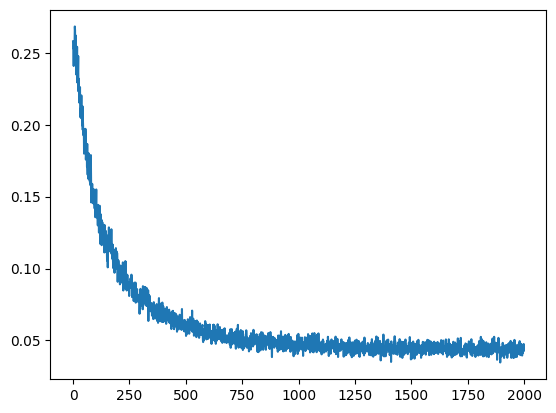

In [20]:
import matplotlib.pyplot as plt
Loss_occupancy = [loss['Loss_occupancy'] for loss in Loss_dict_list]
Loss_occupancy = np.array(Loss_occupancy)
plt.plot(Loss_occupancy)

In [21]:
# try transverse the local deformed heart to canonical space
print('R:', paraheart.R)
print('T:', paraheart.T)
rotation = paraheart.R.detach().cpu()
translation = paraheart.T.detach().cpu()
# transform the R and T to affine matrix
from pytorch3d.transforms import axis_angle_to_matrix
R = axis_angle_to_matrix(rotation).view(3,3)
T = translation.view(3,1)

R: Parameter containing:
tensor([[ 0.2232,  0.8443, -1.0220]], device='cuda:3', requires_grad=True)
T: Parameter containing:
tensor([[-0.1844, -0.1455,  0.0316]], device='cuda:3', requires_grad=True)


In [22]:
print(rotation, translation)

tensor([[ 0.2232,  0.8443, -1.0220]]) tensor([[-0.1844, -0.1455,  0.0316]])


In [23]:
R_ex = torch.eye(4)
R_ex[:3,:3] = R
R_T = R.T 
affine_in = torch.eye(4)

# first translation, then rotation
affine_in[:3,3] = -(R_T@T.squeeze().cpu())
# left mutple = right multiple inverse
affine_in[:3,:3] =  R_T @ affine_in[:3,:3] 
affine_in[3, 3] = 1.0
print(affine_in)


affine = torch.eye(4)
affine[:3,:3] = R
affine[:3,3] = T.squeeze().cpu() 
affine[3, 3] = 1.0
print(affine.inverse())

tensor([[ 0.2459, -0.6600, -0.7099, -0.0282],
        [ 0.8217,  0.5304, -0.2085,  0.2353],
        [ 0.5141, -0.5320,  0.6728, -0.0039],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
tensor([[ 0.2459, -0.6600, -0.7099, -0.0282],
        [ 0.8217,  0.5304, -0.2085,  0.2353],
        [ 0.5141, -0.5320,  0.6728, -0.0039],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])


In [24]:
affine_in.device

device(type='cpu')

In [25]:
# set the changed paraheart to the original. 
paraheart.R = torch.Tensor([0, 0, 0]).view(1,3).to(paraheart.device)
paraheart.T = torch.Tensor([0, 0, 0]).view(1,3).to(paraheart.device)

current_mesh2 = paraheart.rendering()

In [26]:
affine_trans = affine_in.to(paraheart.device)
affine_torch_new = affine_trans @ affine_tem
coordinate_map_tem_new = dut.get_coord_map_3d_normalized(label_tem.shape[-3:], 
                                                         affine_torch_new)


Pt_lv_new = coordinate_map_tem_new[0, Z_lv, Y_lv, X_lv]
Pt_rv_new = coordinate_map_tem_new[0, Z_rv, Y_rv, X_rv]
Pt_cav_new = coordinate_map_tem_new[0, Z_cav, Y_cav, X_cav]
Pt_bg_new = coordinate_map_tem_new[0, Z_bg, Y_bg, X_bg]


points_bi_new = torch.cat([Pt_rv_new, Pt_lv_new], dim=0)
points_lv_new = Pt_lv_new
points_outoflv_new = torch.cat([Pt_rv_new, Pt_cav_new, Pt_bg_new], dim=0)

sample_num = 2000
sample_lv_new = points_lv_new[np.random.choice(points_lv_new.shape[0], 
                                               sample_num, replace=False)]
sample_outoflv_new = points_outoflv_new[np.random.choice(points_outoflv_new.shape[0], 
                                                           sample_num, replace=False)]


In [27]:
print(affine.shape, affine_tem.shape)

torch.Size([4, 4]) torch.Size([4, 4])


In [28]:
# new mesh groundtruth, inverse of the affine 
grid_trans_in = (affine_tem.inverse() @ affine.to(paraheart.device)).unsqueeze(0)[:, :3,:]
print(grid_trans_in.shape)
new_affine_grid_in = F.affine_grid(grid_trans_in, 
                                (1, 1, 200, 200, 200), 
                                align_corners=True)

label_torch_iso_cano = F.grid_sample(label_tem, 
                                new_affine_grid_in, 
                                mode='nearest', 
                                padding_mode='zeros', 
                                align_corners=True)
mesh_gt_lv_cano = cubify((label_torch_iso_cano==2).squeeze(1).float(), 0.5)

torch.Size([1, 3, 4])


In [29]:
coordinate_map_np_new = coordinate_map_tem_new[0].detach().cpu().numpy()

pl = pv.Plotter(notebook=True)
interval = 1
if label_tem.shape[-3] > 20:
    interval = 2
if label_tem.shape[-3] > 50:
    interval = 10
for i in range(0, label_tem.shape[-3], interval):

    x, y, z = coordinate_map_np_new[i,...,0], coordinate_map_np_new[i,...,1], coordinate_map_np_new[i,...,2]

    grid = pv.StructuredGrid(x, y, z)

    color_gt = (label_tem[0,0,i].cpu().numpy().T.flatten() ==2).astype(np.float32)
    
    raw_image = label_tem[0,0,i].cpu().numpy().T.flatten()

    color_opacity = np.ones_like(color_gt)*0.8

    color_opacity[color_gt == 0] = 0.2

    color_gt = raw_image*(1-color_gt) + color_gt

    pl.add_mesh(grid, 
                scalars = color_gt, 
                cmap = 'gray_r',
                show_scalar_bar = False, 
                opacity = color_opacity, 
                clim=[0,1])
    
out_ghd_mesh = paraheart.rendering()

# trimesh_current_bi = paraheart.rendering_bi_ventricle()
# trimesh_current_bi = pv.wrap(trimesh_current_bi)
# pl.add_mesh(trimesh_current_bi, color='blue', opacity=0.2)

trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), 
                                     out_ghd_mesh.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.8, show_edges=True, show_vertices=False)


# pl.add_points(sample_lv_new.detach().cpu().numpy(), color='green', point_size=5)
# pl.add_points(sample_outoflv_new.detach().cpu().numpy(), color='red', point_size=2)

trimesh_gt_lv_cano = trimesh.Trimesh(mesh_gt_lv_cano.verts_packed().detach().cpu().numpy(), 
                               mesh_gt_lv_cano.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_gt_lv_cano, color='red', opacity=0.1)



pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')

pl.add_axes()
pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…